In [114]:
import pandas as pd
import matplotlib.pyplot as plt

file_path = "../../data/spring_2025_data/cleaned_alldata_with_urbanization.csv"
data = pd.read_csv(file_path)

In [115]:
# Aggregating data by location (Lat, Long) to capture seasonal behavior trends
# Using the mean to summarize each seasonal attribute over time for each unique location

seasonal_columns = [
    "Leaves_fresh",
    "Leaves_mature",
    "Leaves_old",
    "Flowers_bud",
    "Flowers_open",
    "Flowers_male",
    "Flowers_Female",
    "Fruits_unripe",
    "Fruits_ripe",
    "Fruits_open",
]

# Aggregating by Lat and Long
aggregated = data.groupby(["Lat", "Long"])[seasonal_columns].mean().reset_index()

# Display the aggregated data to review the summary statistics
aggregated.head()


,Lat,Long,Leaves_fresh,Leaves_mature,Leaves_old,Flowers_bud,Flowers_open,Flowers_male,Flowers_Female,Fruits_unripe,Fruits_ripe,Fruits_open
0,-38.25502,100.00000,2.0,1.0,1.0,1.0,2.0,0.0,0.0,0.0,0.0,0.0
1,-38.20166,100.00000,0.0,0.0,0.0,2.0,2.0,-2.0,-2.0,0.0,0.0,-2.0
2,-36.19894,100.00000,2.0,1.0,1.0,0.0,-2.0,0.0,0.0,0.0,0.0,-2.0
3,-32.92713,23.85847,0.0,2.0,1.0,0.0,0.0,-2.0,-2.0,0.0,2.0,-2.0
4,-29.91685,100.00000,2.0,2.0,0.0,0.0,0.0,-2.0,-2.0,2.0,2.0,1.0


In [116]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN

aggregated_filled = aggregated.fillna(-2)

# Separate Lat and Long for clustering
lat_long = aggregated_filled[["Lat", "Long"]].values
seasonal_data = aggregated_filled.drop(["Lat", "Long"], axis=1)

# Scale the seasonal data
scaler = StandardScaler()
seasonal_data_scaled = scaler.fit_transform(seasonal_data)

# Using DBSCAN with default settings for now; parameters may need tuning
dbscan = DBSCAN(eps=1.5, min_samples=10)
clusters = dbscan.fit_predict(seasonal_data_scaled)

# Add cluster labels back to the original data
aggregated_filled["Cluster"] = clusters

# Display the resulting clusters to understand groupings
aggregated_filled["Cluster"].value_counts(), aggregated_filled.head()


( 0     33626
 -1      1524
  1        63
  7        51
  3        35
  9        25
  4        17
  5        12
  2        10
  6        10
  11       10
  8         7
  10        7
  12        5
 Name: Cluster, dtype: int64,
         Lat       Long  Leaves_fresh  Leaves_mature  Leaves_old  Flowers_bud  \
 0 -38.25502  100.00000           2.0            1.0         1.0          1.0   
 1 -38.20166  100.00000           0.0            0.0         0.0          2.0   
 2 -36.19894  100.00000           2.0            1.0         1.0          0.0   
 3 -32.92713   23.85847           0.0            2.0         1.0          0.0   
 4 -29.91685  100.00000           2.0            2.0         0.0          0.0   
 
    Flowers_open  Flowers_male  Flowers_Female  Fruits_unripe  Fruits_ripe  \
 0           2.0           0.0             0.0            0.0          0.0   
 1           2.0          -2.0            -2.0            0.0          0.0   
 2          -2.0           0.0             0.0      

In [117]:
import geopandas as gpd
from shapely.geometry import Point

# Convert Lat/Long data to geometric points and plot on a basemap of India (Kerala region focus)
# Loading a base map with Indian states boundaries for reference
# Kerala-specific state boundary can be used to better contextualize the data

# Create geometry column using Lat and Long for Kerala points
geometry = [
    Point(xy) for xy in zip(aggregated_filled["Long"], aggregated_filled["Lat"])
]
kerala_gdf = gpd.GeoDataFrame(aggregated_filled, geometry=geometry)

# Load India states shapefile for reference and filter Kerala (using any available map layer if present)
try:
    india_states = gpd.read_file(gpd.datasets.get_path("naturalearth_lowres"))
    kerala_boundary = india_states[
        (india_states["name"] == "India") & (india_states["geometry"].type == "Polygon")
    ]

    # Plot Kerala with clusters overlay
    fig, ax = plt.subplots(figsize=(12, 12))
    kerala_boundary.plot(ax=ax, color="lightgrey", edgecolor="black")
    kerala_gdf.plot(
        column="Cluster", ax=ax, cmap="tab20", markersize=10, legend=True, alpha=0.6
    )

    plt.title("Geographic Clustering of Seasonal Behavior in Kerala with Basemap")
    plt.xlabel("Longitude")
    plt.ylabel("Latitude")
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.show()

except Exception as e:
    str(e)


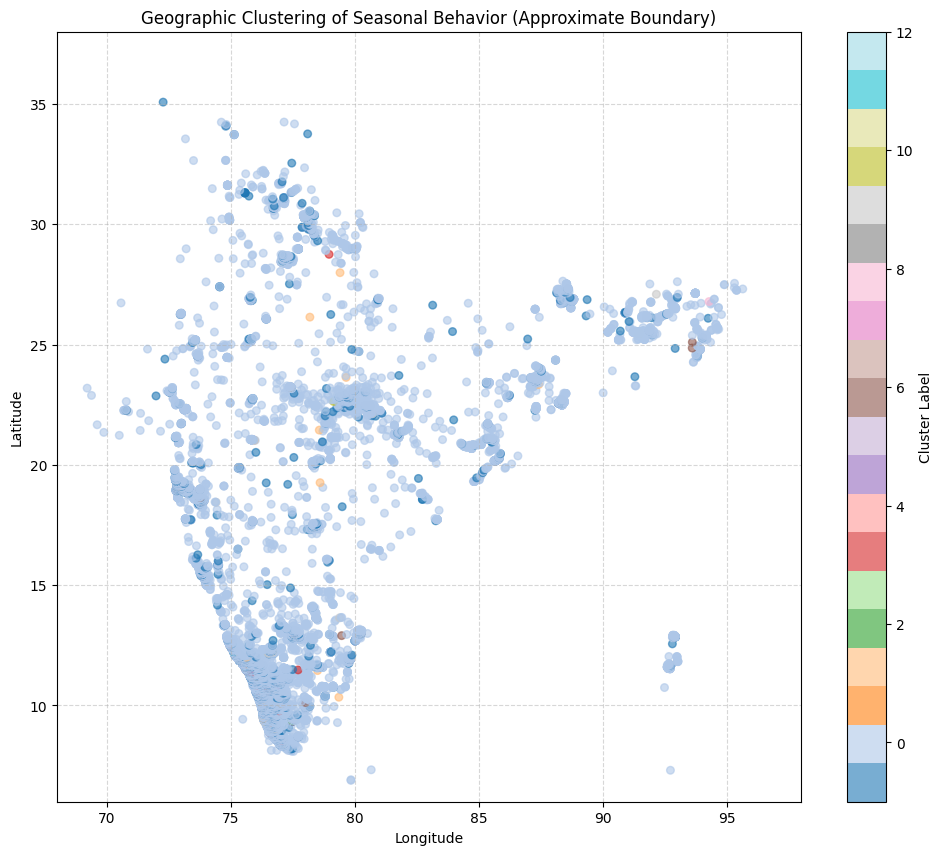

In [118]:
# Redrawing the Kerala clustering with an estimated outline using latitude and longitude boundaries for visualization purposes
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 10))

scatter = plt.scatter(
    aggregated_filled["Long"],
    aggregated_filled["Lat"],
    c=aggregated_filled["Cluster"],
    cmap="tab20",
    s=30,
    alpha=0.6,
)

plt.xlim(68, 98)
plt.ylim(6, 38)

plt.colorbar(scatter, label="Cluster Label")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Geographic Clustering of Seasonal Behavior (Approximate Boundary)")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()


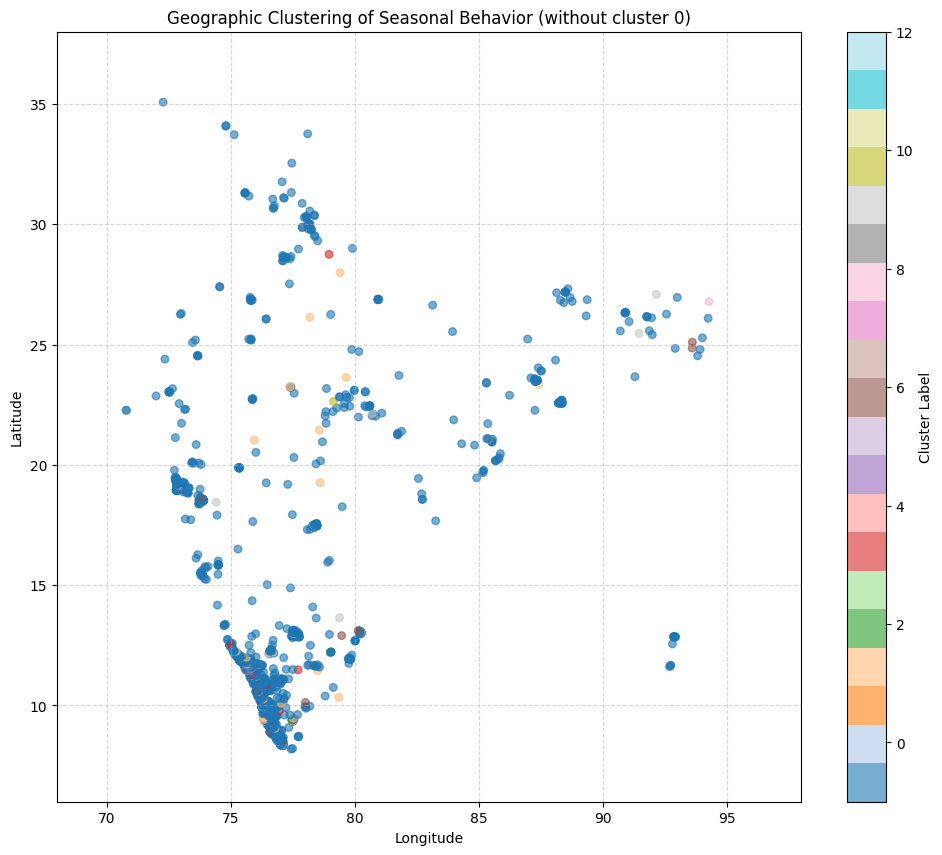

In [119]:
kerala_clusters_no_main = aggregated_filled[aggregated_filled["Cluster"] != 0]

# Plot the remaining clusters without Cluster 0
plt.figure(figsize=(12, 10))
scatter = plt.scatter(
    kerala_clusters_no_main["Long"],
    kerala_clusters_no_main["Lat"],
    c=kerala_clusters_no_main["Cluster"],
    cmap="tab20",
    s=30,
    alpha=0.6,
)
plt.colorbar(scatter, label="Cluster Label")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Geographic Clustering of Seasonal Behavior (without cluster 0)")
plt.grid(True, linestyle="--", alpha=0.5)
plt.xlim(68, 98)
plt.ylim(6, 38)
plt.show()


## Urbanization Clustering


In [120]:
urbanization_clusters = {}

for pop_bin in range(10):
    # Filter data for Kerala and for the specific year
    pop_data = data[(data["pop_bin"] == pop_bin)]

    if len(pop_data) == 0:
        continue

    pop_aggregated = (
        pop_data.groupby(["Lat", "Long"])[seasonal_columns].mean().reset_index()
    )

    # Handle missing values by marking them as absence (-2) as before
    pop_aggregated = pop_aggregated.fillna(-2)

    # Standardize seasonal data (excluding Lat and Long for spatial reference)
    seasonal_data = pop_aggregated.drop(["Lat", "Long"], axis=1)
    scaler = StandardScaler()
    seasonal_data_scaled = scaler.fit_transform(seasonal_data)

    # Clustering using DBSCAN for the specific year
    dbscan = DBSCAN(
        eps=1.5, min_samples=10
    )  # Parameters may be adjusted based on clustering needs
    clusters = dbscan.fit_predict(seasonal_data_scaled)

    pop_aggregated["Cluster"] = clusters
    urbanization_clusters[pop_bin] = pop_aggregated


In [ ]:
import math
import matplotlib.pyplot as plt


def plot_grid(df_dict, title, fmt_subtitle, num_rows=2):
    num_plots = len(df_dict)
    num_cols = math.ceil(num_plots / num_rows)

    fig, axs = plt.subplots(num_rows, num_cols, figsize=(5 * num_cols, 5 * num_rows))
    fig.suptitle(title, fontsize=16)

    axs = axs.flatten() if num_plots > 1 else [axs]

    for i, (key, val) in enumerate(df_dict.items()):
        ax = axs[i]
        ax.scatter(
            val["Long"],
            val["Lat"],
            c=val["Cluster"],
            cmap="tab20",
            s=15,
            alpha=0.6,
        )
        ax.set_title(fmt_subtitle(key))
        ax.set_xlim(68, 98)
        ax.set_ylim(6, 38)
        ax.grid(True, linestyle="--", alpha=0.5)
        ax.set_xlabel("Longitude")
        ax.set_ylabel("Latitude")

    # Remove unused subplots
    for j in range(len(df_dict), len(axs)):
        fig.delaxes(axs[j])

    plt.tight_layout(rect=[0, 0, 1, 0.94])
    plt.show()

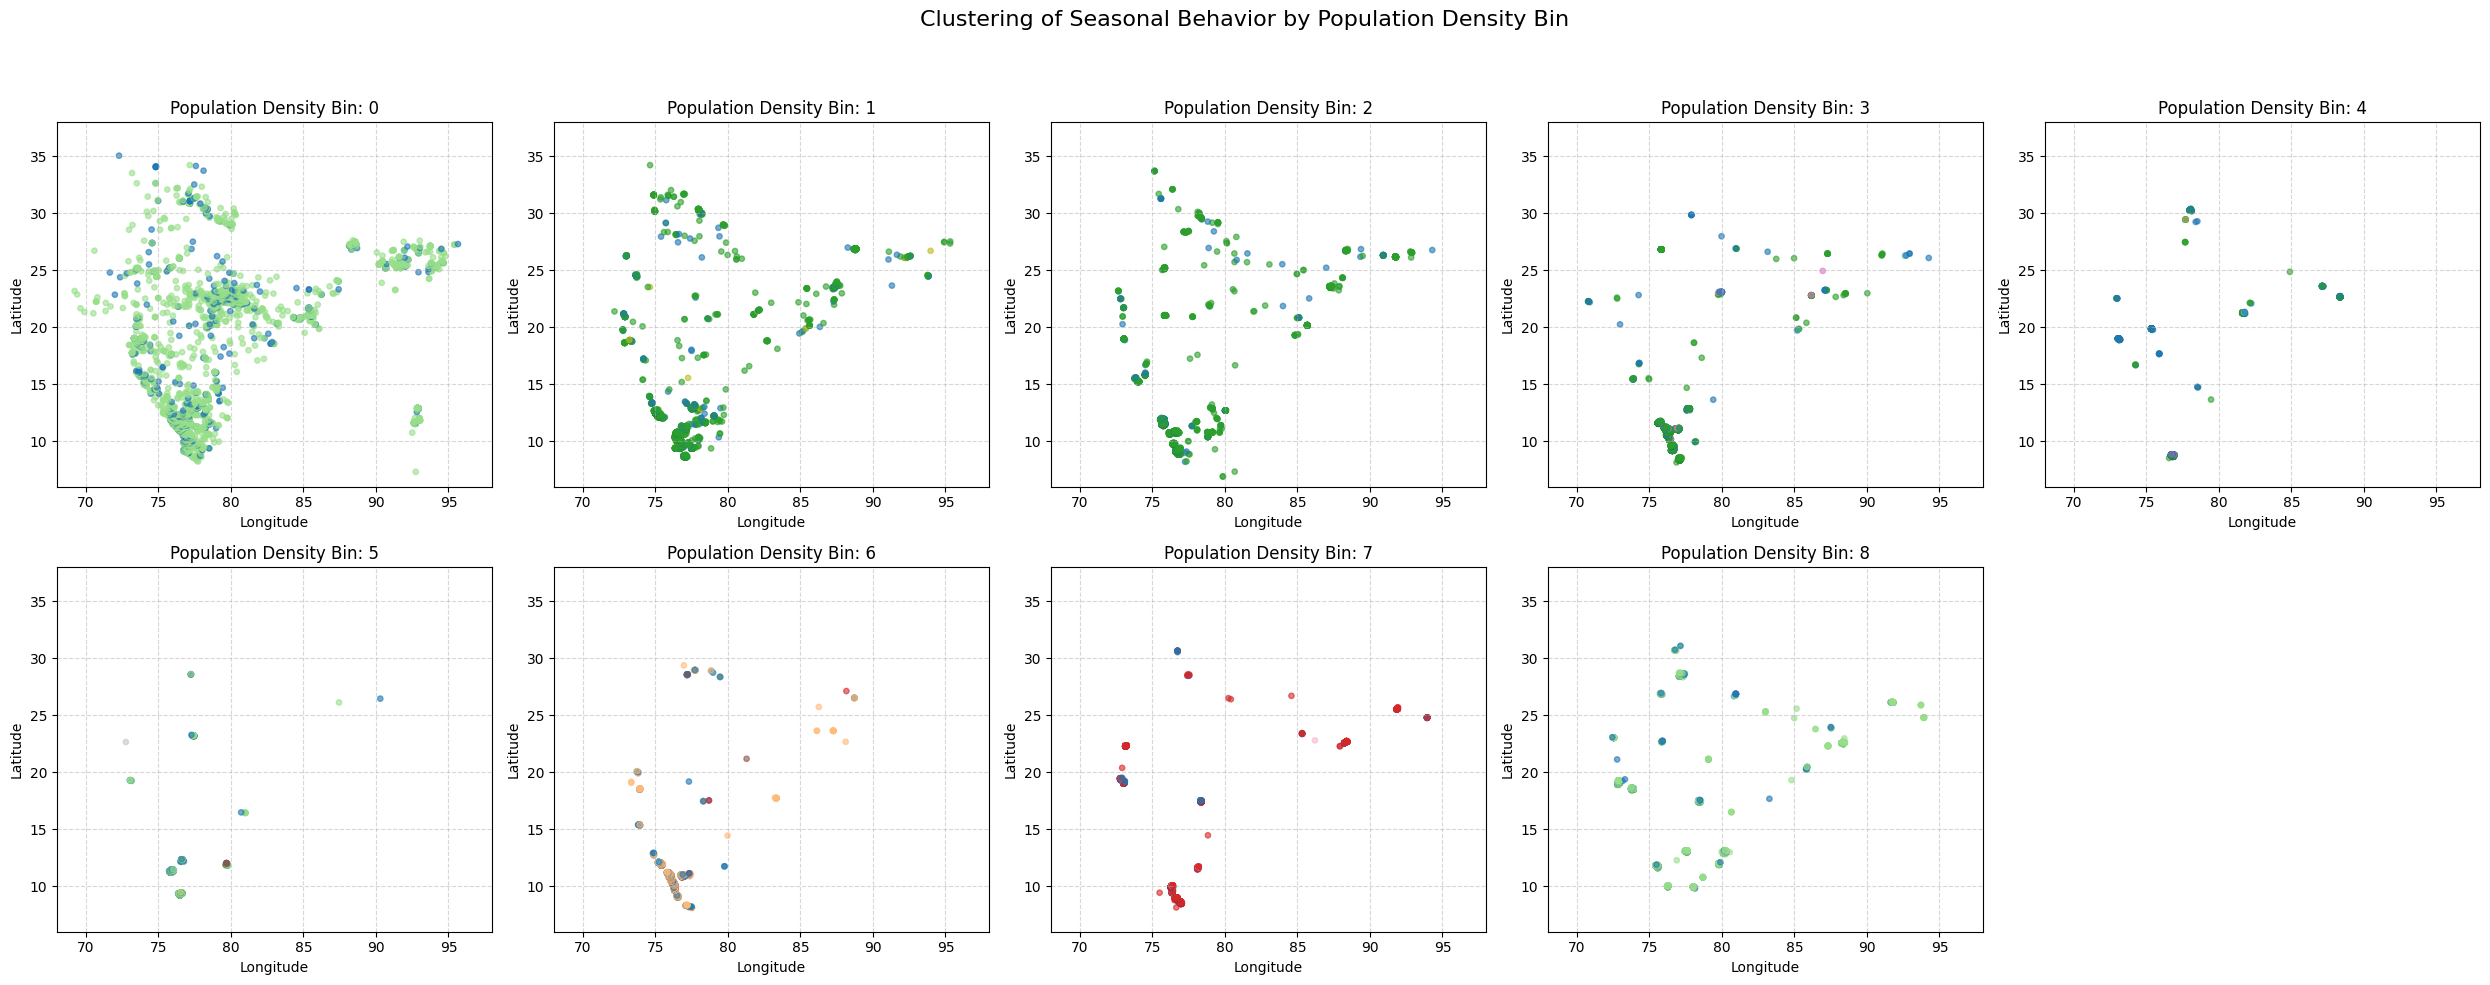

In [125]:
plot_grid(
    urbanization_clusters,
    "Clustering of Seasonal Behavior by Population Density Bin",
    lambda x: f"Population Density Bin: {x}",
)

In [82]:
radiance_clusters = {}

for radiance_dummy in range(2):
    # Filter data for Kerala and for the specific year
    rad_data = data[(data["high_radiance"] == radiance_dummy)]

    if len(rad_data) == 0:
        continue

    rad_aggregated = (
        rad_data.groupby(["Lat", "Long"])[seasonal_columns].mean().reset_index()
    )

    # Handle missing values by marking them as absence (-2) as before
    rad_aggregated = rad_aggregated.fillna(-2)

    # Standardize seasonal data (excluding Lat and Long for spatial reference)
    seasonal_data = rad_aggregated.drop(["Lat", "Long"], axis=1)
    scaler = StandardScaler()
    seasonal_data_scaled = scaler.fit_transform(seasonal_data)

    # Clustering using DBSCAN for the specific year
    dbscan = DBSCAN(
        eps=1.5, min_samples=10
    )  # Parameters may be adjusted based on clustering needs
    clusters = dbscan.fit_predict(seasonal_data_scaled)

    rad_aggregated["Cluster"] = clusters
    radiance_clusters[radiance_dummy] = rad_aggregated


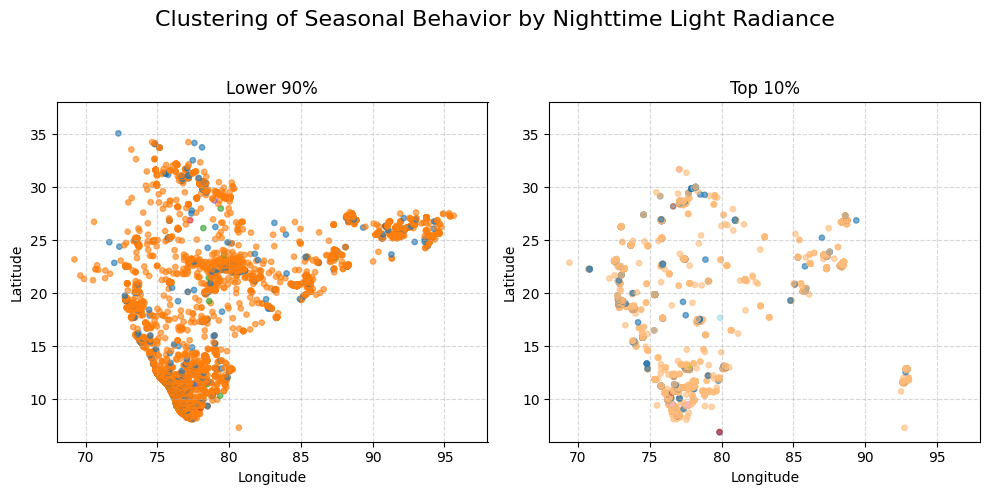

In [104]:
plot_grid(
    radiance_clusters,
    "Clustering of Seasonal Behavior by Nighttime Light Radiance",
    lambda x: "Top 10%" if x == 1 else "Lower 90%",
)